# Project Outline: Predicting Cardiovascular Disease Risk Using CDC BRFSS Data

## 1. Dataset Selection

For this project, I have chosen a dataset that is both extensive and relatively underutilized compared to classic datasets like Iris or Wine. The dataset is the **Behavioral Risk Factor Surveillance System (BRFSS)**, available from the Centers for Disease Control and Prevention (CDC).

- **Data Context:** The BRFSS is the largest continuously conducted health survey system in the world. It collects health-related risk behaviors, chronic health conditions, and preventive service usage from adults in the United States via phone surveys.
- **Why this dataset?** It provides a rich set of variables on health, social, and economic factors, and is not among the typical datasets used in introductory data science projects.

**Links:**
- [BRFSS Introduction](https://www.cdc.gov/brfss/index.html)
- [BRFSS Data Documentation](https://www.cdc.gov/brfss/data_documentation/index.htm)
- [2023 BRFSS Data Download](https://www.cdc.gov/brfss/annual_data/annual_2023.html)

---

## 2. Learning Question

**Main Question:**  
*Can we predict whether an individual has ever been diagnosed with a heart attack based on their health, social, and economic factors?*

- **Target variable (Y):** Ever diagnosed with a heart attack? (categorical: Yes/No/Other)
- **Predictor variables (X):**
  - *Health Factors:* Age, BMI, frequency of health checkups, family history of disease
  - *Social & Economic Factors:* Education, income, access to healthcare and insurance

**Relevance:**  
Understanding these risk factors is critical, as cardiovascular disease is the leading cause of death in the US. This project could help:
- **Individuals:** Remind them of the importance of healthy lifestyle choices.
- **Policymakers:** Guide policy for reducing heart disease prevalence and improving healthcare access.
- **Companies (e.g., food/consumer staples):** Encourage product offerings or campaigns that support healthy living.

---

## 3. Dataset Details

- **Size:** Over 425,000 survey responses are available for recent years, ensuring ample data for robust analysis.
- **Problem Type:** Primarily a *classification* problem (predicting “Yes” or “No” for heart attack diagnosis). If appropriate, I might also explore regression techniques to estimate risk probabilities or model feature impacts.

---

## 4. Model Selection and Justification

Given the project’s goals and dataset characteristics, I propose to try several models:

- **Logistic Regression:**  
  A classic method for binary classification. If I recode the outcome as “Yes” or “No,” logistic regression will help identify which features are most predictive.
- **Decision Trees / Random Forests:**  
  Useful for handling categorical variables and non-linear relationships. Random forests can also help with feature importance analysis and reduce overfitting.
- **k-Nearest Neighbors (k-NN):**  
  As a baseline, I may use k-NN for comparison, though it may not scale as well with very large datasets.

**Potential Challenges:**
- **Class Imbalance:** There may be many more respondents without a heart attack than with one, which could bias models.
- **Survivorship Bias:** Only living respondents are included, which is important to note when interpreting results.

---

## 5. Summary

This project will use the CDC BRFSS dataset to explore and model the risk factors for heart attacks in the US population, using a range of machine learning techniques suitable for classification. The findings could inform individuals, policymakers, and organizations about the most significant predictors of heart disease, and support efforts to promote healthier lifestyles.


In [2]:
# Standard imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import itertools

# Required for modeling and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report,ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson


## Section 1 - Data and Pre-Processing

**Steps in this section**



1. Read the raw data downloaded from the CDC website.
2. Select columns related to cardiovascular diseases and other relevant features. Assign meaningful names to these columns.
3. Check the dataset for missing values and calculate the percentage of missing data. Treat missing values appropriately.
4. Code variables in line with CDC documentation and create appropriate classes.


**Read raw data**

In [5]:

# Load raw CDC data (2023) from the specified path
cdc_raw_2023 = pd.read_sas(
    r'G:\My Drive\PROFESSIONAL\MAS24\Courses\M569_STAT_LRN\assignment\FINAL\cdc\raw\LLCP2023XPT\LLCP2023.XPT', 
    format='xport'
)
print('\nRaw data shape:', cdc_raw_2023.shape)

# List of columns to retain for cardiovascular disease analysis
data_cols_to_keep = [
    '_MICHD',        # Ever reported coronary heart disease (CHD) or myocardial infarction (MI)
    '_RFHYPE6',      # Hypertension risk factor
    '_RFCHOL3',      # Cholesterol risk factor  
    '_RFBMI5',       # Obesity status based on BMI > 25
    '_RFSMOK3',      # Smoking risk factor
    'EXERANY2',      # Indicator of recent exercise
    '_TOTINDA',      # Any physical activity in the last 30 days   
    '_RFDRHV8',      # Heavy drinking risk factor
    'DIFFWALK',      # Difficulty walking
    'CHECKUP1',      # Frequency of health checkups
    # Socio-economic factors
    '_HLTHPL1',      # Health plan coverage
    '_AGEG5YR',      # Age group (5-year bins)
    '_EDUCAG',       # Education level
    'INCOME3'        # Income category 
]

# Mapping of raw variable names to descriptive names
variable_name_mapping = {
    '_MICHD': 'has_heart_disease',             # CHD or MI indicator
    '_RFHYPE6': 'hypertension_risk',           # Hypertension risk factor
    '_RFCHOL3': 'cholesterol_risk',            # Cholesterol risk factor
    '_RFBMI5': 'obese_status',                 # Obesity (BMI > 25)
    '_RFSMOK3': 'smoking_risk',                # Smoking risk factor
    'EXERANY2': 'exercised_recently',          # Any exercise in the last 30 days
    '_TOTINDA': 'physically_active',           # Physical activity indicator
    '_RFDRHV8': 'heavy_drinking_risk',         # Heavy drinking risk factor
    'DIFFWALK': 'difficulty_walking',          # Difficulty walking
    'CHECKUP1': 'checkup_frequency',           # Health checkup frequency
    '_HLTHPL1': 'has_health_plan',             # Health plan coverage
    '_AGEG5YR': 'age_group',                   # Age group (5-year bins)
    '_EDUCAG': 'education_level',              # Education level
    'INCOME3': 'income_category'               # Income category
}

# Extract relevant columns and assign descriptive names
cvd = cdc_raw_2023.loc[:, data_cols_to_keep].copy()
cvd.columns = list(variable_name_mapping.values())
print('\nCVD data shape:', cvd.shape)


Raw data shape: (433323, 350)

CVD data shape: (433323, 14)


**User Defined Functions - Section 1** 


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_missing_count_and_plot(input_df, missing_threshold=5):
    """
    Calculates missing value counts and percentages for each column in the DataFrame,
    displays a bar plot, and prints a summary of unique categories per column.

    Parameters:
    - input_df (pd.DataFrame): The input DataFrame.
    - missing_threshold (float): Threshold (%) for indicating missing value concern on plot.

    Returns:
    - None
    """
    # Calculate missing values count and percentage for each column
    missing_count = input_df.isnull().sum()
    missing_percent = (input_df.isnull().mean() * 100).round(2)
    
    # Combine results into a DataFrame for plotting
    missing_df = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing %': missing_percent
    })
    
    # Plot missing count and percent as side-by-side bars
    plt.figure(figsize=(12, 8))
    missing_df.plot(kind='bar', secondary_y='Missing %', colormap='tab10', legend=True)
    plt.title("Missing Value Count and Percentage")
    plt.xlabel("Column Name")
    plt.xticks(rotation=90, ha='right')
    plt.axhline(missing_threshold, color='orange', linestyle=':', linewidth=2, label='Threshold')
    plt.tight_layout()
    print('\n' + '*' * 100)
    plt.show()
    
    # Print unique value categories and percentages for each column
    summary = []
    for col in input_df.columns:
        value_percent = (input_df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        num_unique = value_percent.shape[0]
        summary.append({
            'Column': col,
            'Num Unique': num_unique,
            'Value Percents': value_percent.to_dict()
        })
    
    summary_df = pd.DataFrame(summary)
    print('\nUnique value summary by column:\n')
    print(summary_df)
    print('\n' + '*' * 100)

def delete_missing_and_replace_col_values(
    in_df, col_name, missing_codes, 
    c1=99, c1_replace=99, 
    c2=999, c2_replace=999, 
    c3=9999, c3_replace=9999, 
    c4=99999, c4_replace=99999
):
    """
    Removes rows with specified missing codes in a column and replaces coded values as defined.

    Parameters:
    - in_df (pd.DataFrame): The input DataFrame.
    - col_name (str): The column to process.
    - missing_codes (list): List of codes to treat as missing and delete.
    - c1, c2, c3, c4 (int): Coded values to replace.
    - c1_replace, c2_replace, c3_replace, c4_replace (int): Replacement values.

    Returns:
    - pd.DataFrame: DataFrame with rows deleted and values replaced in the specified column.
    """
    # Remove rows with specified missing codes
    cleaned_df = in_df[~in_df[col_name].isin(missing_codes)].copy()
    
    # Replace coded values in the column
    replace_dict = {c1: c1_replace, c2: c2_replace, c3: c3_replace, c4: c4_replace}
    cleaned_df.loc[:, col_name] = cleaned_df[col_name].replace(replace_dict)
    
    return cleaned_df

**Check missing values in input dataset**


****************************************************************************************************


<Figure size 1200x800 with 0 Axes>

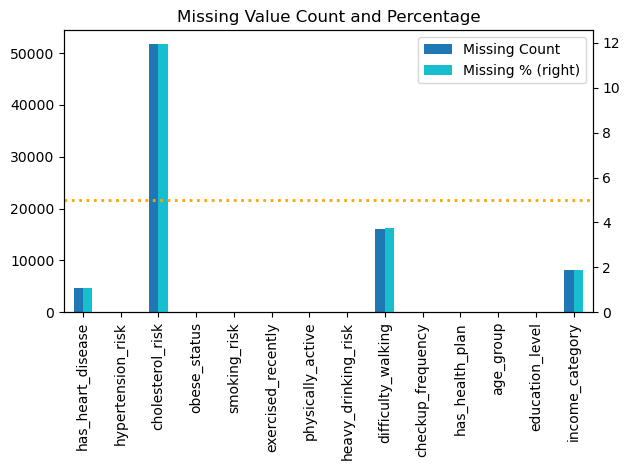


Unique value summary by column:

                 Column  Num Unique  \
0     has_heart_disease           3   
1     hypertension_risk           3   
2      cholesterol_risk           4   
3          obese_status           3   
4          smoking_risk           3   
5    exercised_recently           5   
6     physically_active           3   
7   heavy_drinking_risk           3   
8    difficulty_walking           5   
9     checkup_frequency           8   
10      has_health_plan           3   
11            age_group          14   
12      education_level           5   
13      income_category          14   

                                       Value Percents  
0                  {2.0: 90.56, 1.0: 8.38, nan: 1.06}  
1                 {1.0: 58.89, 2.0: 40.67, 9.0: 0.44}  
2     {1.0: 50.62, 2.0: 36.67, nan: 11.96, 9.0: 0.76}  
3                  {2.0: 62.2, 1.0: 28.45, 9.0: 9.35}  
4                 {1.0: 84.26, 2.0: 10.42, 9.0: 5.32}  
5   {1.0: 75.05, 2.0: 24.66, 7.0: 0.21, 9.0:

In [9]:
calculate_missing_count_and_plot(input_df=cvd, missing_threshold= 5)

**Null Tretament** 
- Given the large dataset, we will delete null values, typically coded as 7 or 9. Categories will be combined as appropriate based on the CDC data dictionary, and assigned codes such as 0, 1, or 2. Please note that ordinal values are not always necessary. As each variable is coded differently, they will be treated separately.


Cleaned data shape: (267825, 14)

****************************************************************************************************


<Figure size 1200x800 with 0 Axes>

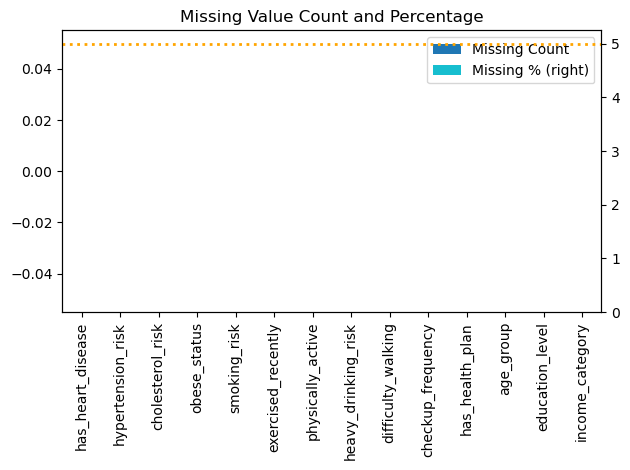


Unique value summary by column:

                 Column  Num Unique  \
0     has_heart_disease           2   
1     hypertension_risk           2   
2      cholesterol_risk           2   
3          obese_status           2   
4          smoking_risk           2   
5    exercised_recently           2   
6     physically_active           2   
7   heavy_drinking_risk           2   
8    difficulty_walking           2   
9     checkup_frequency           5   
10      has_health_plan           2   
11            age_group          13   
12      education_level           4   
13      income_category          11   

                                       Value Percents  
0                             {0.0: 90.95, 1.0: 9.05}  
1                            {0.0: 56.65, 1.0: 43.35}  
2                            {0.0: 57.69, 1.0: 42.31}  
3                            {1.0: 71.36, 0.0: 28.64}  
4                            {0.0: 89.41, 1.0: 10.59}  
5                            {1.0: 77.38, 0.

In [11]:
# Drop any remaining rows with null values
cvd_clean = cvd.dropna()

# Clean and recode each variable according to CDC data dictionary

# has_heart_disease: 1 = Yes, 2 = No (recode to 0), blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean, 
    col_name='has_heart_disease', 
    missing_codes=[''],
    c1=2, c1_replace=0
)

# hypertension_risk: 1 = No (0), 2 = Yes (1), 9 = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='hypertension_risk',
    missing_codes=[9],
    c1=1, c1_replace=0,
    c2=2, c2_replace=1
)

# cholesterol_risk: 1 = No (0), 2 = Yes (1), 9/blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='cholesterol_risk',
    missing_codes=['', 9],
    c1=1, c1_replace=0,
    c2=2, c2_replace=1
)

# obese_status: 1 = No (0), 2 = Yes (1), 9/blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='obese_status',
    missing_codes=['', 9],
    c1=1, c1_replace=0,
    c2=2, c2_replace=1
)

# smoking_risk: 1 = No (0), 2 = Yes (1), 9/blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='smoking_risk',
    missing_codes=['', 9],
    c1=1, c1_replace=0,
    c2=2, c2_replace=1
)

# exercised_recently: 1 = Yes (1), 2 = No (0), 7/9/blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='exercised_recently',
    missing_codes=['', 7, 9],
    c1=1, c1_replace=1,
    c2=2, c2_replace=0
)

# physically_active: 1 = Yes (1), 2 = No (0), 7/9/blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='physically_active',
    missing_codes=['', 7, 9],
    c1=1, c1_replace=1,
    c2=2, c2_replace=0
)

# heavy_drinking_risk: 1 = No (0), 2 = Yes (1), 7/9/blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='heavy_drinking_risk',
    missing_codes=['', 7, 9],
    c1=1, c1_replace=0,
    c2=2, c2_replace=1
)

# difficulty_walking: 1 = Yes (1), 2 = No (0), 7/9/blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='difficulty_walking',
    missing_codes=['', 7, 9],
    c1=1, c1_replace=1,
    c2=2, c2_replace=0
)

# checkup_frequency: 1-4 = ordinal, 8 = Never (code as 5), 7/9/blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='checkup_frequency',
    missing_codes=['', 7, 9],
    c1=8, c1_replace=5
)

# has_health_plan: 1 = Yes (1), 2 = No (0), 7/9/blank = missing
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='has_health_plan',
    missing_codes=['', 7, 9],
    c1=1, c1_replace=1,
    c2=2, c2_replace=0
)

# age_group: 14 = don't know/refused (missing)
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='age_group',
    missing_codes=[14]
)

# education_level: 9 = don't know/refused (missing)
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='education_level',
    missing_codes=[9]
)

# income_category: 77/99/blank = don't know/refused (missing)
cvd_clean = delete_missing_and_replace_col_values(
    in_df=cvd_clean,
    col_name='income_category',
    missing_codes=[77, 99, '']
)

print('\nCleaned data shape:', cvd_clean.shape)

# Confirm no missing values in the cleaned dataset
calculate_missing_count_and_plot(input_df=cvd_clean)

## Summary - Section 1 - Data and Pre-Processing
- Given the large dataset, we can afford to delete rows with missing values.
- All variables have been coded appropriately according to the CDC data codebook.
- Many variables are categorical, which is perfectly acceptable for our analysis. Most are binary, but some have multiple classes. If needed, we can convert multi-class variables into binary classes using one-hot encoding.
- There is a noticeable class imbalance in the target variable `has_heart_disease`, with the majority of cases being "No".
- The target variable for analysis is `has_heart_disease`.
- Multi-class categorical columns: `['checkup_frequency', 'age_group', 'education_level', 'income_category']`
- Binary categorical columns: `['hypertension_risk', 'cholesterol_risk', 'obese_status', 'smoking_risk', 'exercised_recently', 'physically_active', 'heavy_drinking_risk', 'difficulty_walking', 'has_health_plan']`

## Section 2 - Modeling
We are looking to test the following hypotheses with this model:

- Can we predict if a person has suffered a stroke or heart attack based on health, activity, social, and economic factors?
- What are the most important features in the list that can help predict this risk?
- Starting with logistic regression, what statistical models can help predict this classification?
- Additionally, apart from clinical and health parameters, is there a role for income, education, and healthcare availability in predicting the risk of developing cardiovascular disease (CVD)?

**Steps in this section:**

- Define the various functions and code blocks used in this analysis.
- Select the best features for the classification model using various metrics and cross-validation techniques.
- Run the classification model, starting with logistic regression on the data, and improve any features or model specifications as needed.
- Test and interpret the outputs of the model.
- Run other similar classification models to see if we can improve the results and to validate the findings of the logistic regression model.
 

**User defined functions - Section 2**

In [15]:
def run_corr_matrix (input_df):
    '''
    runs corr matrix and plots sns heatmap, needs input df
    '''
    corr_matrix = input_df.corr()
    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", square=True, cbar=True)
    plt.title("Correlation Matrix Heatmap - Input features")
    plt.show()


def run_logit_classification(input_df, y_col_name):
    '''
    Splits the data into training and validation and runs logit regression 
    You get features, coeffients,  summary stats of the model    
    '''

    # Splitting data into training and testing sets
    X_train, X_test, Y_train, Y_test = train_test_split(input_df.drop(y_col_name, axis=1) ,
                                                        input_df.loc[:,y_col_name], test_size=0.2, random_state=42)
    
    # Create and fit the linear regression model
    model = LogisticRegression(max_iter=50000)
    model.fit(X_train, Y_train)
    
    # Predict on the testing set
    Y_pred = np.round(model.predict(X_test)) # rounded

    coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
    })
    
    print ("\n********************Features & Coefficients ********************")
    
    print (coef_df)
    
    # Calculate Classification Report
    acc = classification_report(Y_test, Y_pred)
    print ("\n*******************Classification Report********************")
    print(acc)
    
    
    # Display confusion matrix
    confusion_matrix = pd.crosstab(Y_test, Y_pred, rownames=['Actual'], colnames=['Predicted'])
    sns.heatmap(confusion_matrix, annot=True,fmt='g',cmap="Blues")
    
    plt.title('Logistic Regression on - ' + y_col_name)
    print ("\n*********************Confusion Matrix***************************")
    plt.show()
    print ("\n****************************************************************")


def run_logit_classification_multiclass_features(input_df, y_col_name, multi_class_cols=None):
    '''
    Splits the data into training and validation and runs logistic regression.
    Multi-class categorical columns are one-hot encoded.
    Prints summary stats, classification report, and confusion matrix heatmap.

    Parameters:
        input_df (pd.DataFrame): The input dataframe.
        y_col_name (str): The name of the target column.
        multi_class_cols (list): List of multi-class categorical column names to one-hot encode.
    '''
    # Default to empty list if no multi_class_cols passed
    if multi_class_cols is None:
        multi_class_cols = []

    # One-hot encode multi-class columns (drop first to avoid multicollinearity)
    df_encoded = pd.get_dummies(input_df, columns=multi_class_cols, drop_first=False)

    # Splitting data
    X_train, X_test, Y_train, Y_test = train_test_split(
        df_encoded.drop(y_col_name, axis=1),
        df_encoded[y_col_name],
        test_size=0.2, random_state=42
    )
    
    # Fit logistic regression
    model = LogisticRegression(max_iter=5000)
    model.fit(X_train, Y_train)
    
    # Predict class labels
    Y_pred = model.predict(X_test)

    # Print coefficients
    coef_df = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': model.coef_[0]
    })
    print("Coefficients:\n", coef_df)
    
    # Classification report
    print("\nClassification Report:\n", classification_report(Y_test, Y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Logistic Regression on - ' + y_col_name)
    plt.show()

def balance_classes_by_random_sampling(input_df, y_variable,random_state_var=42):
    """
    Randomly downsample the majority class in input_df so that both classes in y_variable are balanced.
    Returns a new balanced DataFrame called balanced_df.
    """
    # Get class counts
    class_counts = input_df[y_variable].value_counts()
    min_class = class_counts.idxmin()
    max_class = class_counts.idxmax()
    n_samples = class_counts.min()

    # Sample from majority class
    df_min = input_df[input_df[y_variable] == min_class]
    df_max = input_df[input_df[y_variable] == max_class].sample(n=n_samples, random_state=random_state_var)

    # Concatenate and shuffle
    balanced_df = pd.concat([df_min, df_max]).sample(frac=1, random_state=42).reset_index(drop=True)
    return balanced_df



def stepwise_selection_aic_bic_cv(df, y_variable, criterion='aic', direction='backward', n_splits=5, random_state=42):
    """
    Stepwise feature selection for logistic regression using AIC/BIC and cross-validation.

    Parameters:
        df (pd.DataFrame): DataFrame with features and target.
        y_variable (str): Name of target column.
        criterion (str): 'aic' or 'bic'.
        direction (str): 'backward' or 'forward'.
        n_splits (int): Number of cross-validation folds.
        random_state (int): Seed for reproducibility.

    Returns:
        best_features (list): Selected features.
        best_cv_score (float): Best mean AIC or BIC across folds.
        history (list): Progression of feature sets and scores.
    """
    X = df.drop(columns=[y_variable])
    y = df[y_variable]
    features = list(X.columns)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    def get_cv_score(X_sub):
        scores = []
        for train_idx, val_idx in skf.split(X_sub, y):
            X_train, X_val = X_sub.iloc[train_idx], X_sub.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            try:
                model = sm.Logit(y_train, sm.add_constant(X_train))
                result = model.fit(disp=0)
                score = result.aic if criterion == 'aic' else result.bic
            except Exception:
                score = np.inf
            scores.append(score)
        return np.mean(scores)

    best_features = features.copy() if direction == 'backward' else []
    best_cv_score = get_cv_score(X[best_features]) if best_features else np.inf
    history = [(best_features.copy(), best_cv_score)]
    improved = True

    while improved and ((direction == 'backward' and len(best_features) > 1) or
                        (direction == 'forward' and len(best_features) < len(features))):
        improved = False
        candidates = []
        if direction == 'backward':
            for feat in best_features:
                candidate_feats = [f for f in best_features if f != feat]
                if not candidate_feats:
                    continue
                score = get_cv_score(X[candidate_feats])
                candidates.append((score, candidate_feats))
        else:  # forward selection
            remaining = [f for f in features if f not in best_features]
            for feat in remaining:
                candidate_feats = best_features + [feat]
                score = get_cv_score(X[candidate_feats])
                candidates.append((score, candidate_feats))

        candidates.sort()
        if candidates and candidates[0][0] < best_cv_score:
            best_cv_score, best_features = candidates[0]
            history.append((best_features.copy(), best_cv_score))
            improved = True

    print ("\n****************************************************")
    print ('Feature Selection using',criterion, 'with',direction,'selection and', n_splits, 'folds validations' )
    print("\nAll features:", features)
    print("\nSelected features:", best_features)
    print('\nBest score (training set) using',criterion,':', score)
    
    print ("****************************************************")

    return best_features



def run_decision_tree(input_df, y_col_name):
    """
    Trains and evaluates a Decision Tree classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix and the decision tree.
    Returns the fitted model and accuracy score.
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit Decision Tree
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Decision Tree Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    # Plot the decision tree (top 3 levels for readability)
    plt.figure(figsize=(16, 6))
    plot_tree(clf, feature_names=X.columns, class_names=[str(cls) for cls in clf.classes_], filled=True, max_depth=3, fontsize=8)
    plt.title("Decision Tree (Top 3 Levels)")
    plt.show()

    return clf, acc

    
def run_random_forest(input_df, y_col_name):
    """
    Trains and evaluates a Random Forest classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix.
    Returns the fitted model and accuracy score.
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit Random Forest
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Random Forest Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    return clf, acc

def run_gradient_boosting(input_df, y_col_name):
    """
    Trains and evaluates a Gradient Boosting classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix.
    Returns the fitted model and accuracy score.
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit Gradient Boosting
    clf = GradientBoostingClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Gradient Boosting Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    return clf, acc

    
def run_svm_classifier(input_df, y_col_name):
    """
    Trains and evaluates a Support Vector Machine (SVM) classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix.
    Returns the fitted model and accuracy score.
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit SVM
    clf = SVC(random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"SVM Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    return clf, acc


def run_knn_classifier(input_df, y_col_name, n_neighbors=5):
    """
    Trains and evaluates a k-Nearest Neighbors (KNN) classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix.
    Returns the fitted model and accuracy score.
    
    Parameters:
        input_df (pd.DataFrame): Input DataFrame.
        y_col_name (str): Name of the target column.
        n_neighbors (int): Number of neighbors to use for KNN (default=5).
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit KNN
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"KNN Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    return clf, acc

**Data Distribution**

- The dataset contains both binary and multi-class features. The target variable (`y`) is binary.
- The mean of `y` confirms that there is a class imbalance in the dataset.

In [17]:
cvd_model = cvd_clean.copy()
cvd_model.describe()


,has_heart_disease,hypertension_risk,cholesterol_risk,obese_status,smoking_risk,exercised_recently,physically_active,heavy_drinking_risk,difficulty_walking,checkup_frequency,has_health_plan,age_group,education_level,income_category
count,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000,267825.000000
mean,0.090466,0.433541,0.423064,0.713604,0.105924,0.773815,0.773815,0.062817,0.157274,1.261910,0.963103,8.022548,3.170238,7.161057
std,0.286848,0.495564,0.494046,0.452078,0.307740,0.418361,0.418361,0.242634,0.364060,0.690571,0.188510,3.334363,0.910166,2.392299
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,5.000000,2.000000,6.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,9.000000,3.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,11.000000,4.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,13.000000,4.000000,11.000000


**Check features correlations**

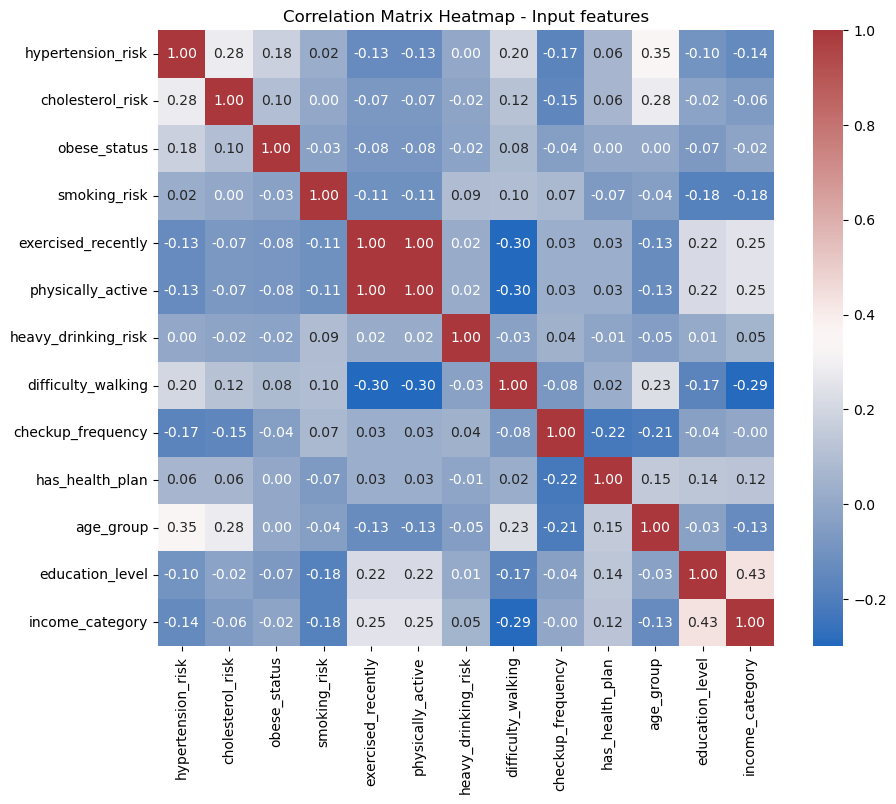

In [19]:
run_corr_matrix(input_df = cvd_model.drop('has_heart_disease', axis=1) ) 


**Feature Correlation**

- We observe that `physically_active` and `exercised_recently` have a 1:1 mapping. Since they measure the same aspect, we should drop one of these features. Similarly, `difficulty_walking` may be redundant if it closely overlaps with another feature.
- `hypertension_risk` and `age` are positively related, which is expected.
- We also see that `education` and `income` are correlated. To avoid redundant data, we need to perform feature selection.

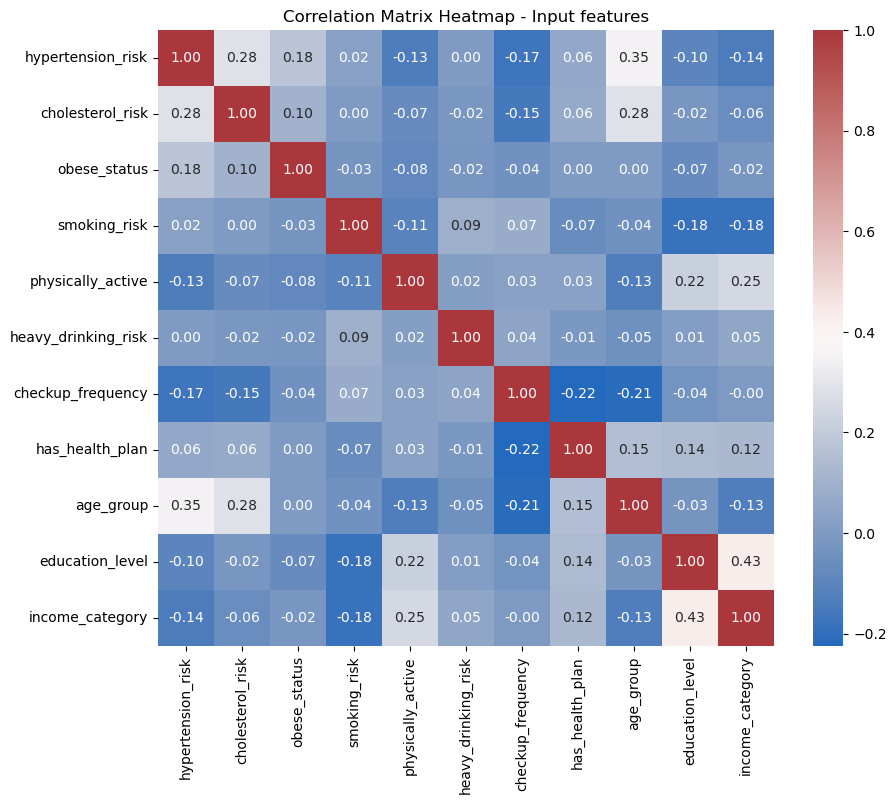

In [21]:
cvd_model = cvd_model.drop(['exercised_recently','difficulty_walking'], axis=1) 
run_corr_matrix(input_df = cvd_model.drop('has_heart_disease', axis=1) ) 

**These numbers look more reasonable now**

- We do not observe any significant correlation between the features, so we can begin modeling with this data.

**We have a binary target variable and are interested in classification. Let us start with a logistic regression classification model as our baseline.**

- This is a simple model and a good starting point. It can help us confirm the class imbalance in the target variable, i.e., many observations with no heart condition (coded as 0).





********************Features & Coefficients ********************
                feature  coefficient
0     hypertension_risk     0.781010
1      cholesterol_risk     0.640654
2          obese_status     0.135276
3          smoking_risk     0.475686
4     physically_active    -0.281737
5   heavy_drinking_risk    -0.322750
6     checkup_frequency    -0.151890
7       has_health_plan     0.099287
8             age_group     0.245119
9       education_level    -0.088817
10      income_category    -0.081510

*******************Classification Report********************
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95     48694
         1.0       0.30      0.00      0.00      4871

    accuracy                           0.91     53565
   macro avg       0.61      0.50      0.48     53565
weighted avg       0.85      0.91      0.87     53565


*********************Confusion Matrix***************************


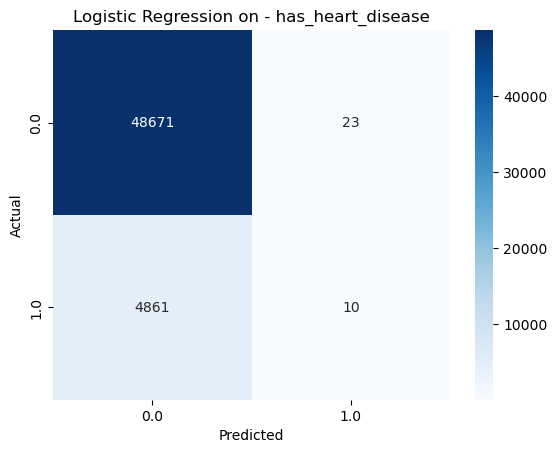


****************************************************************


In [23]:
run_logit_classification(input_df = cvd_model, y_col_name = 'has_heart_disease')

**At first glance, this model demonstrates high accuracy; however, the recall for the minority class indicates an issue.**

- The accuracy appears strong due to class imbalance, as the majority of observations have `y = 0` (no heart disease).
- To develop a better model, we need to address the class imbalance.

**Correcting Class Imbalance**

- One way to correct this is to randomly resample the data so that the majority class has the same number of observations as the minority class.

In [25]:
# This function will randomly sample the majority class to the minority class number of observations
cvd_balanced = balance_classes_by_random_sampling(input_df=cvd_model, y_variable='has_heart_disease',random_state_var=42)
cvd_balanced.groupby('has_heart_disease').count()

,hypertension_risk,cholesterol_risk,obese_status,smoking_risk,physically_active,heavy_drinking_risk,checkup_frequency,has_health_plan,age_group,education_level,income_category
has_heart_disease,,,,,,,,,,,
0.0,24229,24229,24229,24229,24229,24229,24229,24229,24229,24229,24229
1.0,24229,24229,24229,24229,24229,24229,24229,24229,24229,24229,24229


**Re-run our model to see if the correcting class imbalance improves the model**


********************Features & Coefficients ********************
                feature  coefficient
0     hypertension_risk     0.830897
1      cholesterol_risk     0.683659
2          obese_status     0.136469
3          smoking_risk     0.460692
4     physically_active    -0.301199
5   heavy_drinking_risk    -0.196398
6     checkup_frequency    -0.125173
7       has_health_plan     0.010741
8             age_group     0.259630
9       education_level    -0.106600
10      income_category    -0.088607

*******************Classification Report********************
              precision    recall  f1-score   support

         0.0       0.75      0.68      0.71      4893
         1.0       0.70      0.77      0.73      4799

    accuracy                           0.72      9692
   macro avg       0.73      0.72      0.72      9692
weighted avg       0.73      0.72      0.72      9692


*********************Confusion Matrix***************************


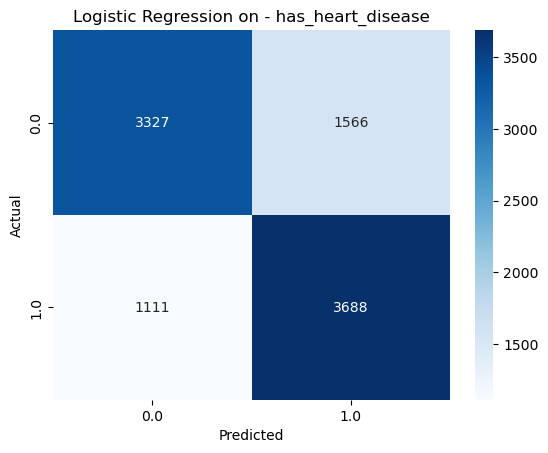


****************************************************************


In [27]:
run_logit_classification(input_df = cvd_balanced, y_col_name = 'has_heart_disease')

**We have corrected class bias in this initial test model**

- We observe good metrics across both classes, and the classification is no longer biased towards any single class.
- The dataset remains large enough, with approximately 24,000 observations, so data size is not a concern.

**After correcting class imbalance, the next step is feature selection**

- We have many features, but not all may add value to the model.
- The goal is to select the most important features from our subset and determine if this improves our results.
- We use stepwise selection with AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) as selection criteria, separately, to identify which features provide the most value.
- Cross-validation is also used to ensure robust results and to utilize the entire dataset for training and testing, rather than relying on a single random split.
- Both AIC and BIC aim to avoid overfitting, but BIC applies a heavier penalty for adding more features.

In [29]:
aic_b_feature=  stepwise_selection_aic_bic_cv(df=cvd_balanced, y_variable='has_heart_disease', criterion='aic', direction='backward', n_splits=5)
bic_b_feature= stepwise_selection_aic_bic_cv(df=cvd_balanced, y_variable='has_heart_disease', criterion='bic', direction='backward', n_splits=5)
aic_f_feature=stepwise_selection_aic_bic_cv(df=cvd_balanced, y_variable='has_heart_disease', criterion='aic', direction='forward', n_splits=5)
bic_f_feature= stepwise_selection_aic_bic_cv(df=cvd_balanced, y_variable='has_heart_disease', criterion='bic', direction='forward', n_splits=5)



****************************************************
Feature Selection using aic with backward selection and 5 folds validations

All features: ['hypertension_risk', 'cholesterol_risk', 'obese_status', 'smoking_risk', 'physically_active', 'heavy_drinking_risk', 'checkup_frequency', 'has_health_plan', 'age_group', 'education_level', 'income_category']

Selected features: ['hypertension_risk', 'cholesterol_risk', 'obese_status', 'smoking_risk', 'physically_active', 'heavy_drinking_risk', 'checkup_frequency', 'age_group', 'education_level', 'income_category']

Best score (training set) using aic : 42570.54365250788
****************************************************

****************************************************
Feature Selection using bic with backward selection and 5 folds validations

All features: ['hypertension_risk', 'cholesterol_risk', 'obese_status', 'smoking_risk', 'physically_active', 'heavy_drinking_risk', 'checkup_frequency', 'has_health_plan', 'age_group', 'education

**Feature Selection**

- Both metrics and methods selected the same set of features!
- One feature, `has_health_plan`, was dropped from the list.
- There is limited evidence from this model that having a health insurance plan has any bearing on whether someone has a heart condition. However, this may be related to a data issue discussed earlier: **this dataset has survivorship bias**—only those who have survived a heart condition responded to this survey. Therefore, we cannot definitively say whether having health insurance might have resulted in saving more lives.
- We will run a logistic classification model using the selected best features.


Final features selected -  ['age_group', 'checkup_frequency', 'cholesterol_risk', 'education_level', 'heavy_drinking_risk', 'hypertension_risk', 'income_category', 'obese_status', 'physically_active', 'smoking_risk']

********************Features & Coefficients ********************
               feature  coefficient
0    physically_active    -0.300142
1    checkup_frequency    -0.125216
2     cholesterol_risk     0.683839
3         obese_status     0.136861
4      income_category    -0.088588
5      education_level    -0.106751
6            age_group     0.259685
7  heavy_drinking_risk    -0.197515
8         smoking_risk     0.459743
9    hypertension_risk     0.832692

*******************Classification Report********************
              precision    recall  f1-score   support

         0.0       0.75      0.68      0.71      4893
         1.0       0.70      0.77      0.73      4799

    accuracy                           0.72      9692
   macro avg       0.73      0.72      0

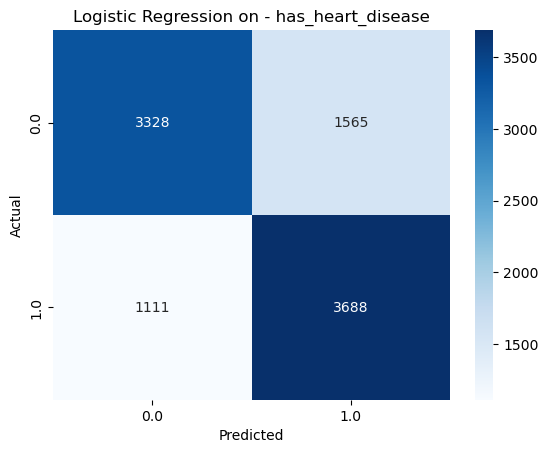


****************************************************************


In [31]:
lists = [aic_b_feature,bic_b_feature,aic_f_feature,bic_f_feature]
   
common = set(lists[0])
for l in lists[1:]:
    common &= set(l)
# all are the same 10 features
print('\nFinal features selected - ',sorted(list(common)))

best_features_with_target = list(common) + ['has_heart_disease']
cvd_best_features = cvd_balanced.loc[:,best_features_with_target]
run_logit_classification(input_df = cvd_best_features, y_col_name = 'has_heart_disease')

**Model Results**

The summary output has the following findings:

- **Accuracy:** The model was correct 72% of the time overall in predicting if a person has had a heart condition.

---

**Class 0.0 (No heart disease):**
- **Precision:** 0.75 — When the model predicts "no heart condition," it is correct 75% of the time.
- **Recall:** 0.69 — Out of all patients who actually do not have a heart condition, the model identifies 69% of them correctly.
- **F1-score:** 0.71 — This is a balanced measure of the model’s ability to avoid false positives and false negatives for this class.

**Class 1.0 (Has heart condition):**
- **Precision:** 0.71 — When the model predicts "heart condition," it is correct 71% of the time.
- **Recall:** 0.76 — Out of all patients who actually have a heart condition, the model identifies 76% of them correctly.
- **F1-score:** 0.73 — This is a balanced measure of the model’s ability to identify true heart condition cases versus mistakes.

---

**More importantly, given the severity of missing out on predicting if someone has a heart condition, the recall numbers for Class 1.0 are higher than for Class 0. This means we are erring on the side of caution; falsely identifying someone as at risk of heart condition is better than missing someone who may potentially have heart disease in the future.**

Macro average (simple average) and weighted average present similar numbers.

---

**Coefficient Interpretation**

| Feature              | Coefficient | Interpretation                                                         |
|----------------------|------------:|-----------------------------------------------------------------------|
| physically_active    |   -0.300142 | Protective: lowers risk of the target condition                       |
| hypertension_risk    |    0.832692 | **Strong positive risk factor**                                       |
| heavy_drinking_risk  |   -0.197515 | Protective: lowers risk (strange results)   |
| income_category      |   -0.088588 | Higher income, slightly protective                                    |
| age_group            |    0.259685 | Older age group, higher risk                                          |
| education_level      |   -0.106751 | Higher education, slightly protective                                 |
| checkup_frequency    |   -0.125216 | Longer time to last checkup, higher risk                              |
| obese_status         |    0.136861 | Slightly increases risk                                               |
| smoking_risk         |    0.459743 | **Strong positive risk factor**                                       |
| cholesterol_risk     |    0.683839 | **Strong positive risk factor**                                       |






**Logistic Regression Model Equation**

The probability that an individual has heart disease (`has_heart_disease = 1`) is given by:

$$
\text{logit}(p) = \beta_0 
- 0.300142 \cdot \text{physically\_active}
+ 0.832692 \cdot \text{hypertension\_risk}
- 0.197515 \cdot \text{heavy\_drinking\_risk}
- 0.088588 \cdot \text{income\_category}
+ 0.259685 \cdot \text{age\_group}
- 0.106751 \cdot \text{education\_level}
- 0.125216 \cdot \text{checkup\_frequency}
+ 0.136861 \cdot \text{obese\_status}
+ 0.459743 \cdot \text{smoking\_risk}
+ 0.683839 \cdot \text{cholesterol\_risk}
$$

Where:
- $p$ is the probability that `has_heart_disease = 1`
- $\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)$
- $\beta_0$ is the model intercept (not shown above; use your model output).

**Final Probability:**

$$
p(\text{has\_heart\_disease}=1) = \frac{1}{1 + \exp(-\text{logit}(p))}
$$

---

**We are aware that the model has a few features that are multi-class, and we want to run one more model by splitting these multi-class features into dummy variables.**

- The following model will run the same analysis, except multi-class features will be converted to binary (dummy) variables.

Coefficients:
                   feature  coefficient
0       physically_active    -0.294394
1        cholesterol_risk     0.685293
2            obese_status     0.144927
3     heavy_drinking_risk    -0.191660
4            smoking_risk     0.451529
5       hypertension_risk     0.829870
6   checkup_frequency_1.0    -0.005038
7   checkup_frequency_2.0    -0.332324
8   checkup_frequency_3.0    -0.298365
9   checkup_frequency_4.0    -0.226669
10  checkup_frequency_5.0     0.040681
11          age_group_1.0    -1.370396
12          age_group_2.0    -1.321955
13          age_group_3.0    -1.214348
14          age_group_4.0    -0.878274
15          age_group_5.0    -0.642481
16          age_group_6.0    -0.421066
17          age_group_7.0    -0.034558
18          age_group_8.0     0.236295
19          age_group_9.0     0.507777
20         age_group_10.0     0.615571
21         age_group_11.0     0.942029
22         age_group_12.0     1.211327
23         age_group_13.0     1.548363
24    educ

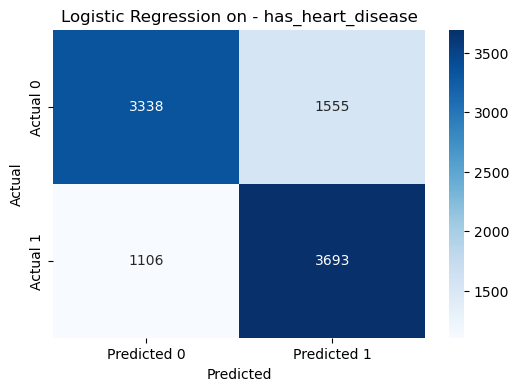

In [33]:
run_logit_classification_multiclass_features(input_df = cvd_best_features, y_col_name = 'has_heart_disease', multi_class_cols=['checkup_frequency', 'age_group', 'education_level', 'income_category'])

**Similar Results but Offer More Granularity and Details**

- Higher education is associated with lower risk of heart diseases.
- Although the data is not perfectly monotonic across all income brackets, generally, lower income households tend to have higher CVD risk compared to higher income households. Note that income and education are usually positively correlated, which is intuitive: higher education may lead to greater awareness and higher income may lead to better food and physical activity choices and improved access to healthcare.
- The shorter the time since the last health checkup, the lower the risk of heart disease.

---

**Other Models**

There are other statistical classification models we would like to implement on this data. The objective is to verify if the results of the logistic regression model are consistent with other methods and to determine if we can find a better performing model. Models we have used include:

- Decision Trees
- Random Forest
- Support Vector Machine (SVM)
- Gradient Boosting
- K-Nearest Neighbours (KNN)

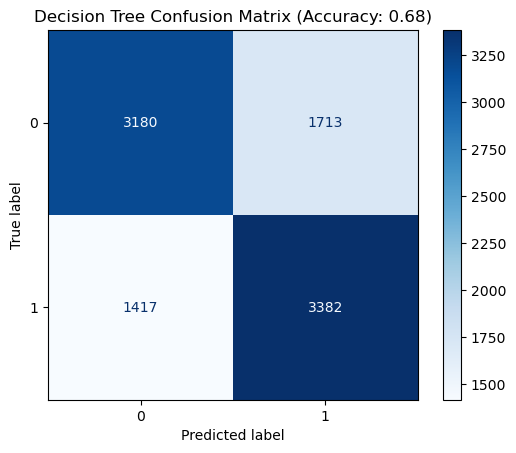

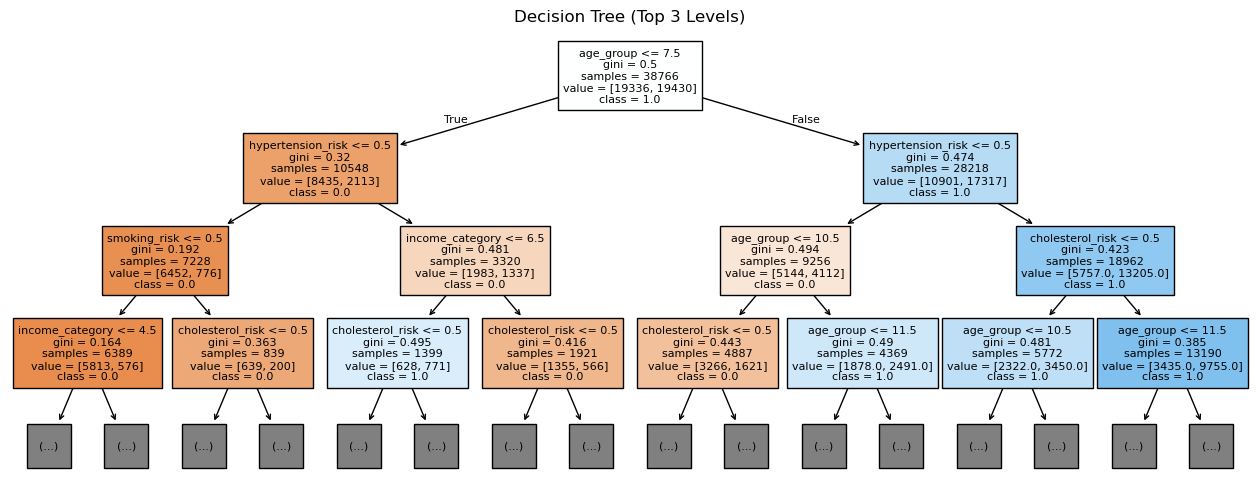

(DecisionTreeClassifier(random_state=42), 0.67705323978539)

In [36]:
run_decision_tree(input_df = cvd_best_features, y_col_name = 'has_heart_disease')

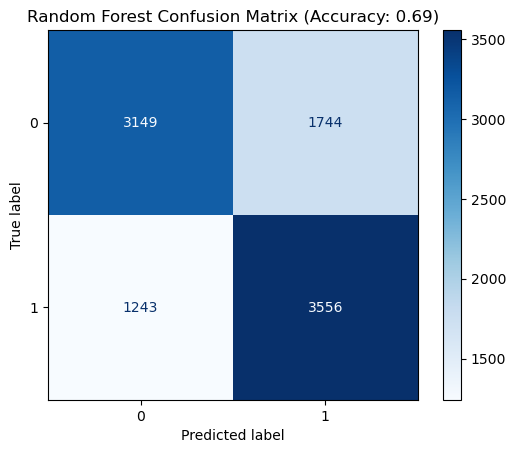

(RandomForestClassifier(random_state=42), 0.6918076764341725)

In [37]:
run_random_forest(input_df = cvd_best_features, y_col_name = 'has_heart_disease')

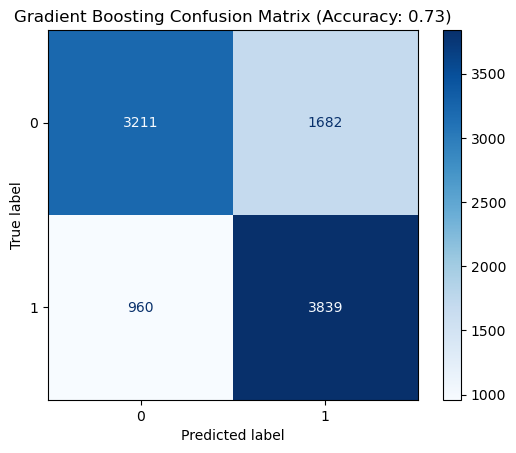

(GradientBoostingClassifier(random_state=42), 0.7274040445728436)

In [38]:
run_gradient_boosting(input_df = cvd_best_features, y_col_name = 'has_heart_disease')

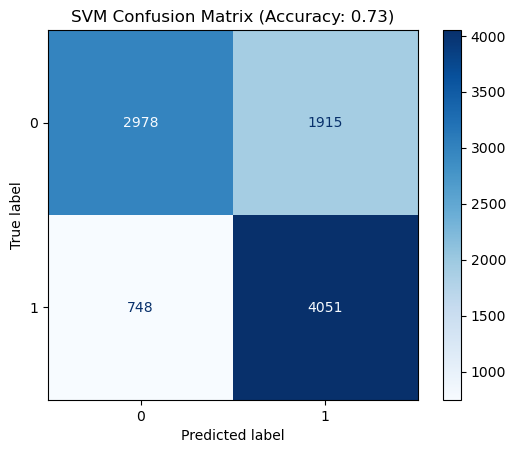

(SVC(random_state=42), 0.7252373091209244)

In [39]:
run_svm_classifier(input_df = cvd_best_features, y_col_name = 'has_heart_disease')

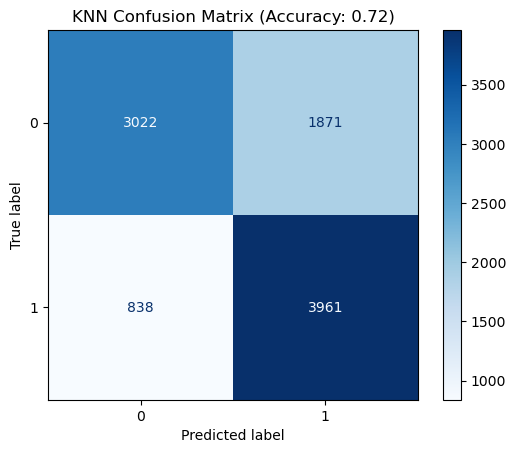

(KNeighborsClassifier(n_neighbors=220), 0.720491126702435)

In [40]:
sample_size_sqrt = int(np.sqrt(cvd_best_features['has_heart_disease'].count()))
run_knn_classifier(input_df = cvd_best_features, y_col_name = 'has_heart_disease', n_neighbors=sample_size_sqrt)

- **We obtain similar results in terms of accuracy from other models.**
- **Gradient Boosting and SVM models show slightly better accuracy, but these warrant a more detailed study to determine if they are truly better than the Logistic Regression model.**

# Section 3 - Summary of Findings

**Key questions addressed in this project**

**Q1. Can we predict if a person has suffered a stroke or heart attack based on health, activity, social, and economic factors?**
- Yes, we can. Our model predicts this outcome with 72% accuracy.

**Q2. What are the most important features for predicting this risk?**

| Feature              | Coefficient | Interpretation                      |
|----------------------|------------:|-------------------------------------|
| hypertension_risk    |    0.83     | Strong positive risk factor         |
| cholesterol_risk     |    0.68     | Strong positive risk factor         |
| smoking_risk         |    0.46     | Strong positive risk factor         |
| physically_active    |   -0.30     | Protective: lowers risk             |
| age_group            |    0.26     | Older age group, higher risk        |

- Hypertension risk, cholesterol risk, and smoking risk are the strongest predictors for heart conditions.
- Being physically active is a protective factor, while older individuals are more likely to suffer from heart conditions.

**Q3. What statistical models help predict this classification besides logistic regression?**
- While we focused on logistic regression for this classification problem, we found that other models, such as decision trees, SVM, and Gradient Boost, yielded similar results. This consistency increases our confidence in the robustness of the identified relationships.

**Q4. Beyond clinical and health parameters, do income, education, and healthcare access play a role in predicting cardiovascular disease (CVD) risk?**

- **Absolutley,** when we expanded the categories we got more insights
- **Age group:** Risk increases significantly for older age groups (age_group_12.0, age_group_13.0 have the highest positive coefficients).
- **Education level:** Higher education levels (education_level_2.0, 3.0, 4.0) are associated with lower risk.
- **Income category:** Higher income categories (income_category_8.0 to 11.0) have more negative coefficients, indicating a protective effect.

---

### Open Questions & Final Comments

- This study models the risk of heart disease based on existing data. However, there is a survivorship bias, as only patients who survived a heart condition such as a heart attack are included in the CDC survey.
- Despite this, the model is not fundamentally flawed. We successfully established relationships between features across health, social, and economic categories and cardiovascular events.
- The classification underscores the benefits of a healthy lifestyle, regular health checkups—especially as one ages—and managing hypertension and stress.
- In addition to health-related features, the study also demonstrates that social and economic factors play a role in developing heart disease. Higher income is linked to better healthcare, preventative care, and nutrition, which help reduce CVD risk.
- Similarly, higher education levels can provide increased awareness of prevention strategies and risk reduction for cardiovascular diseases.


# APPENDIX
**Final Logistic Regression Model Equation**

The probability that an individual has heart disease (`has_heart_disease = 1`) is given by:

$$
\text{logit}(p) = \beta_0 
- 0.300142 \cdot \text{physically\_active}
+ 0.832692 \cdot \text{hypertension\_risk}
- 0.197515 \cdot \text{heavy\_drinking\_risk}
- 0.088588 \cdot \text{income\_category}
+ 0.259685 \cdot \text{age\_group}
- 0.106751 \cdot \text{education\_level}
- 0.125216 \cdot \text{checkup\_frequency}
+ 0.136861 \cdot \text{obese\_status}
+ 0.459743 \cdot \text{smoking\_risk}
+ 0.683839 \cdot \text{cholesterol\_risk}
$$

Where:
- $p$ is the probability that `has_heart_disease = 1`
- $\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)$
- $\beta_0$ is the model intercept (not shown above; use your model output).

**Final Probability:**

$$
p(\text{has\_heart\_disease}=1) = \frac{1}{1 + \exp(-\text{logit}(p))}
$$


**Final Logistic Regression Model Equation with all Binary Features**

$$
\begin{align*}
\text{logit}(p) =\ & \beta_0 \\
&+ 0.685293 \cdot \text{cholesterol\_risk} \\
&+ 0.451529 \cdot \text{smoking\_risk} \\
&+ 0.144927 \cdot \text{obese\_status} \\
&- 0.294394 \cdot \text{physically\_active} \\
&+ 0.829870 \cdot \text{hypertension\_risk} \\
&- 0.191660 \cdot \text{heavy\_drinking\_risk} \\
&- 0.005038 \cdot \text{checkup\_frequency\_1.0} \\
&- 0.332324 \cdot \text{checkup\_frequency\_2.0} \\
&- 0.298365 \cdot \text{checkup\_frequency\_3.0} \\
&- 0.226669 \cdot \text{checkup\_frequency\_4.0} \\
&+ 0.040681 \cdot \text{checkup\_frequency\_5.0} \\
&- 1.370396 \cdot \text{age\_group\_1.0} \\
&- 1.321955 \cdot \text{age\_group\_2.0} \\
&- 1.214348 \cdot \text{age\_group\_3.0} \\
&- 0.878274 \cdot \text{age\_group\_4.0} \\
&- 0.642481 \cdot \text{age\_group\_5.0} \\
&- 0.421066 \cdot \text{age\_group\_6.0} \\
&- 0.034558 \cdot \text{age\_group\_7.0} \\
&+ 0.236295 \cdot \text{age\_group\_8.0} \\
&+ 0.507777 \cdot \text{age\_group\_9.0} \\
&+ 0.615571 \cdot \text{age\_group\_10.0} \\
&+ 0.942029 \cdot \text{age\_group\_11.0} \\
&+ 1.211327 \cdot \text{age\_group\_12.0} \\
&+ 1.548363 \cdot \text{age\_group\_13.0} \\
&- 0.003108 \cdot \text{education\_level\_1.0} \\
&- 0.217372 \cdot \text{education\_level\_2.0} \\
&- 0.204423 \cdot \text{education\_level\_3.0} \\
&- 0.396814 \cdot \text{education\_level\_4.0} \\
&+ 0.335650 \cdot \text{income\_category\_1.0} \\
&+ 0.431568 \cdot \text{income\_category\_2.0} \\
&+ 0.147801 \cdot \text{income\_category\_3.0} \\
&+ 0.178072 \cdot \text{income\_category\_4.0} \\
&- 0.041576 \cdot \text{income\_category\_5.0} \\
&- 0.184024 \cdot \text{income\_category\_6.0} \\
&- 0.218201 \cdot \text{income\_category\_7.0} \\
&- 0.338816 \cdot \text{income\_category\_8.0} \\
&- 0.339879 \cdot \text{income\_category\_9.0} \\
&- 0.376747 \cdot \text{income\_category\_10.0} \\
&- 0.415564 \cdot \text{income\_category\_11.0}
\end{align*}
$$

Where:
- $p$ is the probability that `has_heart_disease = 1`
- $\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)$
- $\beta_0$ is the intercept (get from your model output).

**Final Probability:**

$$
p(\text{has\_heart\_disease}=1) = \frac{1}{1 + \exp(-\text{logit}(p))}
$$